In [92]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import Adam
from torchvision.datasets import MNIST
from torchvision.transforms import transforms

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [4]:
train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='./data', train=False, download=True, transform=transform)

In [11]:
len(train_dataset)
len(test_dataset)

60000

10000

In [12]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [13]:
len(train_loader)
len(test_loader)

1875

313

In [17]:
images, labels = next(iter(train_loader))
images.shape
labels.shape

torch.Size([32, 1, 28, 28])

torch.Size([32])

In [34]:
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()

    # CNN: captures spatial features
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    # MLP
    self.fc1 = nn.Linear(32 * 7 * 7, 128)
    self.fc2 = nn.Linear(128, 10)
    self.dropout = nn.Dropout(0.25)

  def forward(self, x):
    x = F.relu(self.conv1(x))  # [batch, 1, 28, 28] -> [batch, 16, 28, 28]
    x = self.pool(x)  # [batch, 16, 28, 28] -> [batch, 16, 14, 14]

    x = F.relu(self.conv2(x))  # [batch, 16, 14, 14] -> [batch, 32, 14, 14]
    x = self.pool(x)  # [batch, 32, 14, 14] -> [batch, 32, 7, 7]

    # flatten [batch, 32, 7, 7] -> [batch, 1568]
    x = x.view(x.size(0), -1)

    x = F.relu(self.fc1(x))
    x = self.dropout(x)

    return self.fc2(x)

In [78]:
model = CNN()

total = 0
for name, param in model.named_parameters():
  total += param.numel()
  print(f'name: {name:15s} | param shape: {tuple(param.shape)}')
print(f'total: {total}')

name: conv1.weight    | param shape: (16, 1, 3, 3)
name: conv1.bias      | param shape: (16,)
name: conv2.weight    | param shape: (32, 16, 3, 3)
name: conv2.bias      | param shape: (32,)
name: fc1.weight      | param shape: (128, 1568)
name: fc1.bias        | param shape: (128,)
name: fc2.weight      | param shape: (10, 128)
name: fc2.bias        | param shape: (10,)
total: 206922


In [79]:
images, labels = next(iter(train_loader))
outputs = model(images)
outputs.shape

torch.Size([32, 10])

In [80]:
criterion = nn.CrossEntropyLoss()

optimizer = Adam(model.parameters(), lr=0.0001)

In [81]:
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

In [82]:
NUM_EPOCHS = 5

for epoch in range(NUM_EPOCHS):
  # training phase
  print('training phase')

  train_loss_lst = []
  train_acc_lst = []

  _ = model.train()
  for batch_idx, (images, labels) in enumerate(train_loader):
    # clear accumulated grads
    optimizer.zero_grad()

    # forward pass to calc outputs
    outputs = model(images)

    # calc loss
    loss = criterion(outputs, labels)

    # backward pass to calc grads
    loss.backward()

    # update params
    optimizer.step()

    labels_pred = torch.max(outputs, dim=1).indices
    train_loss_lst.append(loss.item())
    train_acc = accuracy_score(labels, labels_pred)
    train_acc_lst.append(train_acc)

    if batch_idx % 200 == 0:
      print(f'batch: {batch_idx:>4}, loss: {loss:.4f} acc: {train_acc:.4f}')

  # validation phase
  print('validation phase')

  val_loss_lst = []
  val_acc_lst = []

  _ = model.eval()
  for batch_idx, (images, labels) in enumerate(test_loader):
    with torch.no_grad():
      outputs = model(images)
      loss = criterion(outputs, labels)

      labels_pred = torch.max(outputs, dim=1).indices
      val_loss_lst.append(loss.item())
      val_acc = accuracy_score(labels, labels_pred)
      val_acc_lst.append(val_acc)

      if batch_idx % 200 == 0:
        print(f'batch: {batch_idx:>4}, loss: {loss:.4f} acc: {val_acc:.4f}')

  history['train_loss'].append(np.mean(train_loss_lst))
  history['val_loss'].append(np.mean(val_loss_lst))
  history['train_acc'].append(np.mean(train_acc_lst))
  history['val_acc'].append(np.mean(val_acc_lst))

training phase
batch:    0, loss: 2.3147 acc: 0.0312
batch:  200, loss: 0.7789 acc: 0.9062
batch:  400, loss: 0.4374 acc: 0.8750
batch:  600, loss: 0.4603 acc: 0.8750
batch:  800, loss: 0.2235 acc: 0.9375
batch: 1000, loss: 0.7173 acc: 0.7500
batch: 1200, loss: 0.3159 acc: 0.9062
batch: 1400, loss: 0.1770 acc: 0.9688
batch: 1600, loss: 0.2410 acc: 0.9062
batch: 1800, loss: 0.1503 acc: 0.9688
validation phase
batch:    0, loss: 0.0758 acc: 1.0000
batch:  200, loss: 0.0752 acc: 1.0000
training phase
batch:    0, loss: 0.1394 acc: 0.9688
batch:  200, loss: 0.1777 acc: 0.9062
batch:  400, loss: 0.3132 acc: 0.9062
batch:  600, loss: 0.0484 acc: 1.0000
batch:  800, loss: 0.0558 acc: 0.9688
batch: 1000, loss: 0.1107 acc: 0.9688
batch: 1200, loss: 0.2005 acc: 0.9688
batch: 1400, loss: 0.4666 acc: 0.8750
batch: 1600, loss: 0.1066 acc: 0.9688
batch: 1800, loss: 0.0302 acc: 1.0000
validation phase
batch:    0, loss: 0.0433 acc: 1.0000
batch:  200, loss: 0.0298 acc: 1.0000
training phase
batch:   

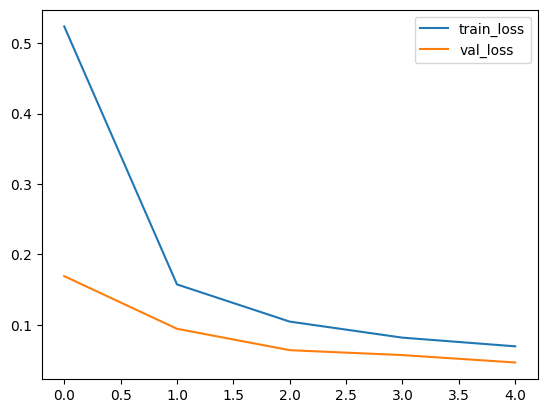

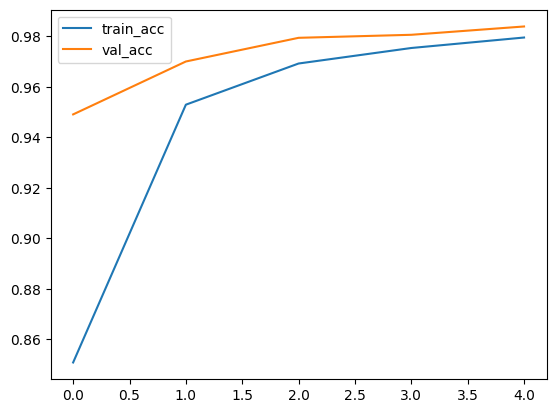

In [91]:
_ = plt.plot(history['train_loss'], label='train_loss')
_ = plt.plot(history['val_loss'], label='val_loss')
_ = plt.legend()

_ = plt.show()

_ = plt.plot(history['train_acc'], label='train_acc')
_ = plt.plot(history['val_acc'], label='val_acc')
_ = plt.legend()

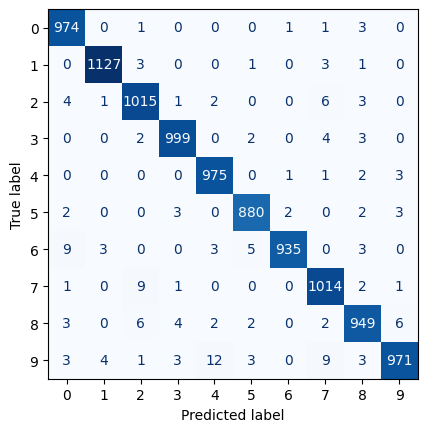

In [101]:
_ = model.eval()

all_labels = []
all_labels_pred = []
with torch.no_grad():
  for batch_idx, (images, labels) in enumerate(test_loader):
    outputs = model(images)
    labels_pred = torch.max(outputs, dim=1).indices
    all_labels.extend(labels.tolist())
    all_labels_pred.extend(labels_pred.tolist())

cm = confusion_matrix(all_labels, all_labels_pred)
cmd = ConfusionMatrixDisplay(cm)
_ = cmd.plot(cmap='Blues', colorbar=False)

In [102]:
torch.save(model.state_dict(), 'mnist-cnn.pth')